In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install hdbscan==0.8.40
!pip install geopandas==1.0.1
!pip install contextily==1.6.2
!pip install shapely==2.0.6

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.preprocessing import StandardScaler

# geographical tools
import geopandas as gpd  # pandas dataframe-like geodataframes for geographical data
import contextily as ctx  # used for obtianing a basemap of Canada
from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

In [3]:
import requests
import zipfile
import io
import os

# URL of the ZIP file on the cloud server
zip_file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

# Directory to save the extracted TIFF file
output_dir = './'
os.makedirs(output_dir, exist_ok=True)

# Step 1: Download the ZIP file
response = requests.get(zip_file_url)
response.raise_for_status()  # Ensure the request was successful
# Step 2: Open the ZIP file in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    # Step 3: Iterate over the files in the ZIP
    for file_name in zip_ref.namelist():
        if file_name.endswith('.tif'):  # Check if it's a TIFF file
            # Step 4: Extract the TIFF file
            zip_ref.extract(file_name, output_dir)
            print(f"Downloaded and extracted: {file_name}")

Downloaded and extracted: Canada.tif


In [4]:
# Write a function that plots clustered locations and overlays them on a basemap.

def plot_clustered_locations(df,  title='Museums Clustered by Proximity'):
    """
    Plots clustered locations and overlays on a basemap.
    
    Parameters:
    - df: DataFrame containing 'Latitude', 'Longitude', and 'Cluster' columns
    - title: str, title of the plot
    """
    
    # Load the coordinates intto a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326")
    
    # Reproject to Web Mercator to align with basemap 
    gdf = gdf.to_crs(epsg=3857)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Separate non-noise, or clustered points from noise, or unclustered points
    non_noise = gdf[gdf['Cluster'] != -1]
    noise = gdf[gdf['Cluster'] == -1]
    
    # Plot noise points 
    noise.plot(ax=ax, color='k', markersize=30, ec='r', alpha=1, label='Noise')
    
    # Plot clustered points, colured by 'Cluster' number
    non_noise.plot(ax=ax, column='Cluster', cmap='tab10', markersize=30, ec='k', legend=False, alpha=0.6)
    
    # Add basemap of  Canada
    ctx.add_basemap(ax, source='./Canada.tif', zoom=4)
    
    # Format plot
    plt.title(title, )
    plt.xlabel('Longitude', )
    plt.ylabel('Latitude', )
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    
    # Show the plot
    plt.show()

In [5]:
# Load data

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/r-maSj5Yegvw2sJraT15FA/ODCAF-v1-0.csv'
df = pd.read_csv(url, encoding = "ISO-8859-1")

In [6]:
# Display df structure

df.head()
df.sample(20)

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
6441,7983,Russell & District Regional Library,..,library or archives,government of manitoba,..,339,main st,R0J 1W0,russell,mb,339 main st,Russell-Binscarth,4616030,46,50.782049,-101.28808
3830,4638,Heritage House,..,heritage or historic site,calgary,..,304,19 av sw,..,calgary,ab,304 19 av sw,Calgary,4806016,48,51.03648135,-114.068854
1464,1734,Bibliotheque Simone-L.-Roy,municipale,library or archives,bibliotheque et archives nationales du québec,..,500,rue grande,G9B 7S3,sept-Îles,qc,"500, rue grande allee",Trois-Rivières,2437067,24,46.2900085,-72.6717546
4002,4881,International Festival of Films On Art (Fifa),festival / special event,festival site,province of québec,..,1380,rue sherbrooke o,H3G 1J5,montréal,qc,"1380, rue sherbrooke o.",Montréal,2466023,24,45.498511,-73.579365
4349,5314,La Vallee Twp,..,library or archives,government of ontario,..,56,church road,P0W 1C0,devlin,on,56 church road,..,..,35,..,..
3965,4836,If3 Festival,guided tour,festival site,province of québec,..,2915,rue ontario e,H2K 1X7,montréal,qc,"2915, rue ontario e.",Montréal,2466023,24,45.537466,-73.549948
2178,2642,Chilliwack Museum & Historical Society Gift Shop,gift shop non-profit # s-9175,museum,chilliwack,..,45820,spadina ave,V2P 1T3,chilliwack,bc,"45820 spadina ave, chilliwack bc v2p 1t3",Chilliwack,5909020,59,49.16897019,-121.956597
518,624,Bancroft Town,..,library or archives,government of ontario,..,14,flint street,K0L 1C0,bancroft,on,14 flint street,..,..,..,..,..
3215,3880,Fort Nelson Historical Society,community/regional museum,museum,canadian museums association,..,..,..,V0C 1R0,fort nelson,bc,p.o. box 716 fort nelson british columbia v0c ...,Northern Rockies,5959007,59,58.8062848,-122.6939592
2527,3049,Danish Canadian National Museum,human history-archaelogy-anthropology or ethno...,museum,canadian museums association,..,..,..,T0M 1V0,spruce view,ab,po box 92 spruce view alberta t0m 1v0 canada,Red Deer County,4808001,48,52.0857224,-114.3105996


In [7]:
# Drop NaNs from the dataframe
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Index                  7972 non-null   int64 
 1   Facility_Name          7972 non-null   object
 2   Source_Facility_Type   7972 non-null   object
 3   ODCAF_Facility_Type    7972 non-null   object
 4   Provider               7972 non-null   object
 5   Unit                   7972 non-null   object
 6   Street_No              7972 non-null   object
 7   Street_Name            7972 non-null   object
 8   Postal_Code            7972 non-null   object
 9   City                   7972 non-null   object
 10  Prov_Terr              7972 non-null   object
 11  Source_Format_Address  7972 non-null   object
 12  CSD_Name               7972 non-null   object
 13  CSDUID                 7972 non-null   object
 14  PRUID                  7972 non-null   object
 15  Latitude             

In [8]:
# Count Facility Type's

df_facility_types = df['ODCAF_Facility_Type'].value_counts()
print(df_facility_types)

ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64


In [9]:
# Filter data frame for museum's

filtered_df = df[df['ODCAF_Facility_Type'] == 'museum']
filtered_df.ODCAF_Facility_Type.value_counts()

ODCAF_Facility_Type
museum    1938
Name: count, dtype: int64

In [10]:
# Selecting only longitude and latitude

df = df[['Latitude', 'Longitude']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Latitude   7972 non-null   object
 1   Longitude  7972 non-null   object
dtypes: object(2)
memory usage: 124.7+ KB


In [17]:
# Remove observations with no coordinates 
df = df[df.Latitude!='..']

df['Latitude'] = df['Latitude'].str.replace(',', '')
df['Longitude'] = df['Longitude'].str.replace(',', '')

# Convert to float
df[['Latitude','Longitude']] = df[['Latitude','Longitude']].astype('float')

In [18]:
# In this case we know how to scale the coordinates. Using standardization would be an error becaues we aren't using the full range of the lat/lng coordinates.
# Since latitude has a range of +/- 90 degrees and longitude ranges from 0 to 360 degrees, the correct scaling is to double the longitude coordinates (or half the Latitudes)
coords_scaled = df.copy()
coords_scaled["Latitude"] = 2*coords_scaled["Latitude"]

In [19]:
min_samples=3 # minimum number of samples needed to form a neighbourhood
eps=1.0 # neighbourhood search radius
metric='euclidean' # distance measure 

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(coords_scaled)

In [20]:
df['Cluster'] = dbscan.fit_predict(coords_scaled)  # Assign the cluster labels

# Display the size of each cluster
df['Cluster'].value_counts()

Cluster
 0     4643
 2      829
 10     515
 3      270
 7      171
-1       84
 14      25
 26      21
 6       20
 11      14
 17      12
 24      10
 22      10
 4        8
 31       7
 12       7
 35       7
 34       6
 15       6
 1        5
 18       5
 32       5
 27       5
 38       4
 8        4
 9        4
 21       4
 19       4
 20       4
 33       4
 16       4
 25       4
 5        3
 13       3
 29       3
 28       3
 23       3
 30       3
 36       3
 37       3
 39       3
Name: count, dtype: int64

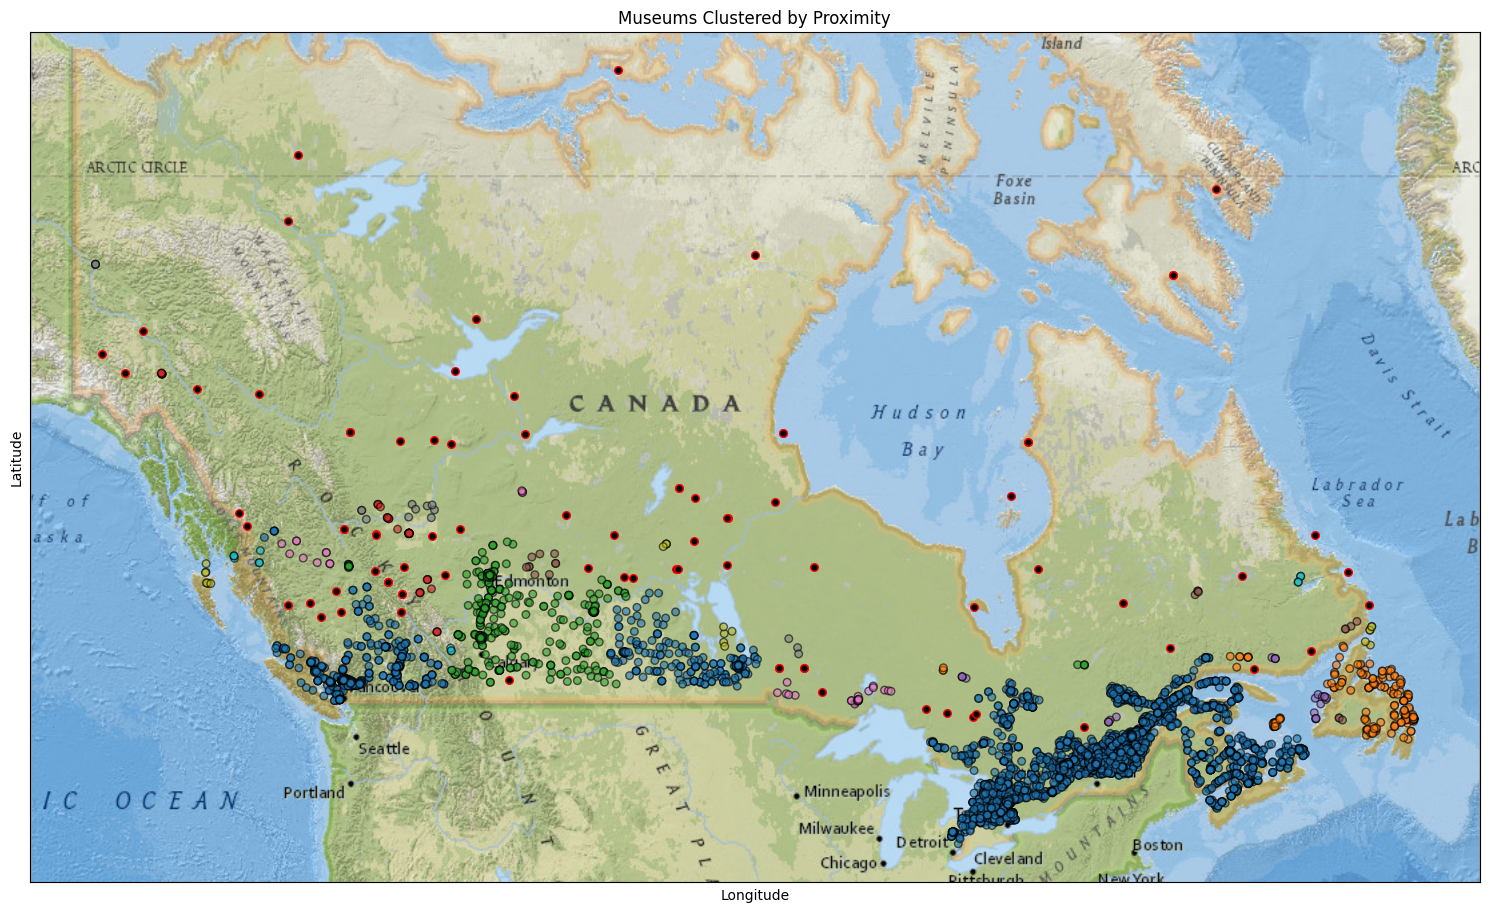

In [21]:
plot_clustered_locations(df, title='Museums Clustered by Proximity')